In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [2]:
train = pd.read_csv('../dataset/train.csv')
print("Shape:", train.shape)
train.head()

Shape: (77299, 11)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [3]:
print("="*50)
print("BASIC INFORMATION")
print("="*50)
print(f"Rows    : {train.shape[0]}")
print(f"Columns : {train.shape[1]}")
print(f"\nData Types:\n{train.dtypes}")

BASIC INFORMATION
Rows    : 77299
Columns : 11

Data Types:
Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
dtype: object


In [4]:
print("="*50)
print("MISSING VALUES")
print("="*50)

missing = pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing %'    : (train.isnull().sum()/len(train))*100
})
print(missing)

MISSING VALUES
               Missing Count  Missing %
Index                      0   0.000000
geohash                    0   0.000000
day                        0   0.000000
timestamp                  0   0.000000
demand                     0   0.000000
RoadType                 600   0.776207
NumberofLanes              0   0.000000
LargeVehicles              0   0.000000
Landmarks                  0   0.000000
Temperature             2495   3.227726
Weather                  797   1.031061


In [5]:
print("="*50)
print("DUPLICATES CHECK")
print("="*50)
dupes = train.duplicated().sum()
print(f"Duplicate rows: {dupes}")
train = train.drop_duplicates()
print(f"After removing: {train.shape[0]} rows")

DUPLICATES CHECK
Duplicate rows: 0
After removing: 77299 rows


DEMAND DISTRIBUTION


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ACER\\OneDrive\\Desktop\\Gridlock\\output\\demand_distribution.png'

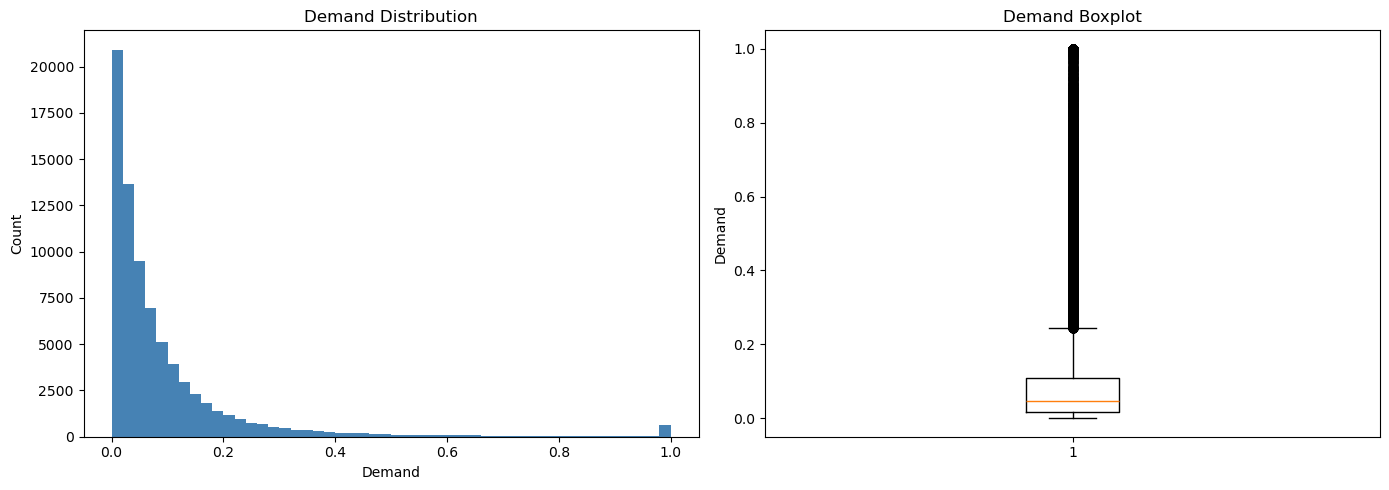

In [ ]:
print("="*50)
print("DEMAND DISTRIBUTION")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histogram
axes[0].hist(train['demand'], bins=50, color='steelblue')
axes[0].set_title('Demand Distribution')
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(train['demand'])
axes[1].set_title('Demand Boxplot')
axes[1].set_ylabel('Demand')

plt.tight_layout()
os.makedirs('../output', exist_ok=True)
plt.savefig('../output/demand_distribution.png')
plt.show()

print(f"Mean   : {train['demand'].mean():.4f}")
print(f"Median : {train['demand'].median():.4f}")
print(f"Std    : {train['demand'].std():.4f}")
print(f"Min    : {train['demand'].min():.4f}")
print(f"Max    : {train['demand'].max():.4f}")